# Customer Churn Prediction Using Machine Learning

## Project Background

Customer churn refers to the situation where customers stop using a company's service

Predicting customer churn is important because companies can identify high-risk customers earlier and develop customer retention strategies.

In this project, machine learning models are used to predict whether a customer is likely to churn based on customer demographic information, service usage, contract type, and payment information.

In [405]:
# Customer Churn Prediction Project

# Import basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("../data/customer_churn.csv")

# Show first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [406]:
df.shape

(7043, 21)

In [407]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [408]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [409]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [410]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [411]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

## Data Cleaning

In this section, the dataset is checked for missing values, incorrect data types, and duplicated records.

The 'TotalCharges' column needs special attention because it represents numerical values but may be stored as an object type.

In [412]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [413]:
df["TotalCharges"].dtype

dtype('O')

In [414]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [415]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [416]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [417]:
df = df.dropna()
df.shape

(7032, 21)

After converting the 'TotalCharges' column from object type to numeric type, 11 missing values were identified.

Since the number of missing records was very small compared with the whole dataset, these rows were removed.

After removing missing values, the dataset was reduced from 7043 records to 7032 records.

In [418]:
df.duplicated().sum()

np.int64(0)

In [419]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

## Exploratory Data Analysis

In this section, exploratory data analysis is conducted to understand the distribution of customer churn and the relationship between important features and churn.

In [420]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [421]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

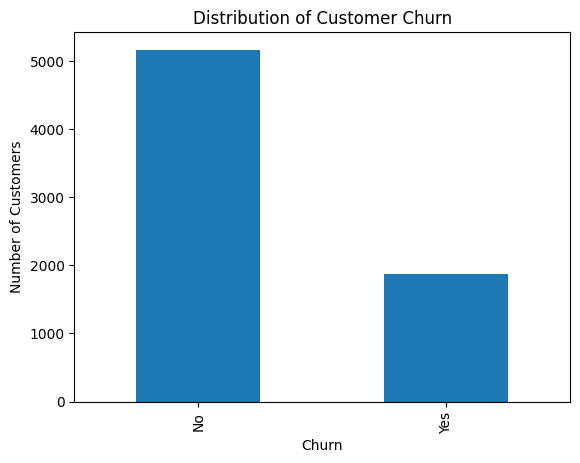

In [422]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [423]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


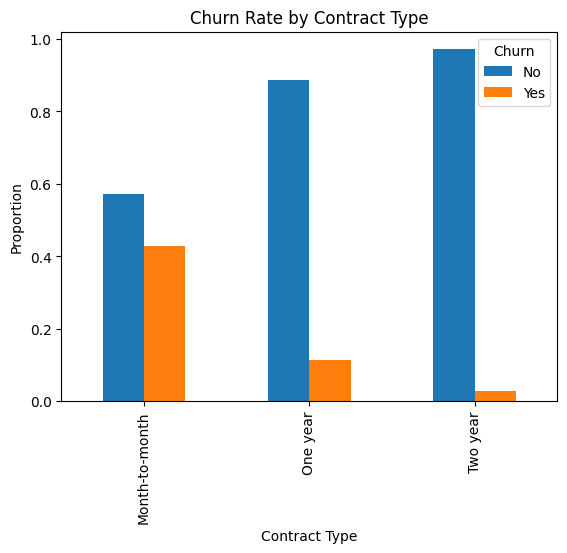

In [424]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index").plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Proportion")
plt.legend(title="Churn")
plt.show()

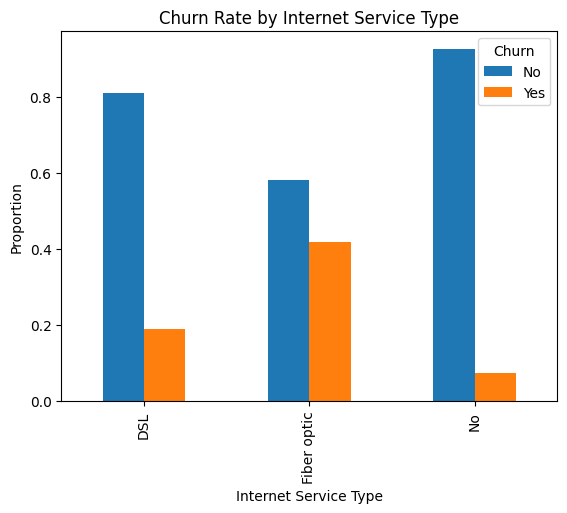

In [425]:
pd.crosstab(df["InternetService"], df["Churn"], normalize="index").plot(kind="bar")

plt.title("Churn Rate by Internet Service Type")
plt.xlabel("Internet Service Type")
plt.ylabel("Proportion")
plt.legend(title="Churn")
plt.show()

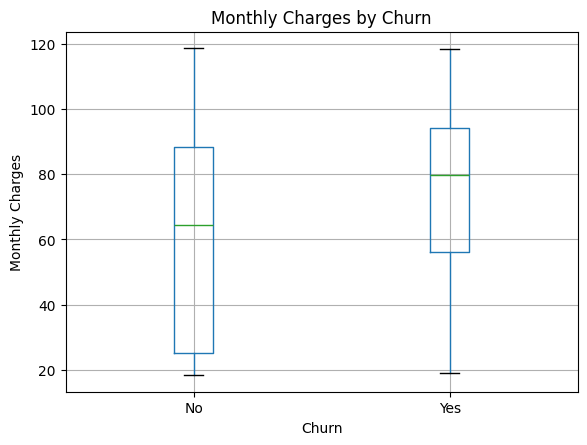

In [426]:
df.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

## Feature Preprocessing

In this section, categorical variables are converted into numerical format so that they can be used by machine learning models.

The target variable 'Churn' is also encoded into binary values, where 'Yes' is converted to 1 and 'No' is converted to 0.

In [427]:
df = df.drop("customerID", axis=1)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [428]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [429]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

display(X.head())
display(y.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [430]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


In [431]:
X.shape

(7032, 30)

In [432]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5625, 30), (1407, 30), (5625,), (1407,))

## Model Training

### Logistic Regression

In this section, machine learning models are trained to predict customer churn.

The first model used is Logistic Regression, which is a common baseline model for binary classification problems.

In [433]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [434]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

/Users/yu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/yu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weigh

LogisticRegression(max_iter=1000)

In [435]:
y_pred_log = log_model.predict(X_test_scaled)

y_pred_log[:10]

/Users/yu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

In [436]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_log = accuracy_score(y_test, y_pred_log)

accuracy_log

0.8038379530916845

In [437]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [438]:
cm_log = confusion_matrix(y_test, y_pred_log)

cm_log

array([[916, 117],
       [159, 215]])

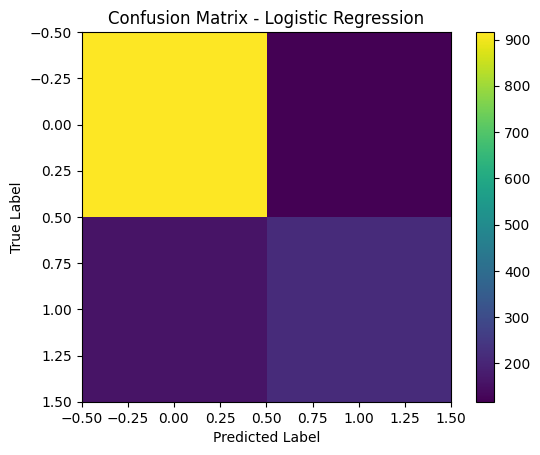

In [439]:
import matplotlib.pyplot as plt

plt.imshow(cm_log)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.show()

### Decision Tree Model

Decision Tree is a tree-based classification model. It is easy to interpret, but it may overfit the training data if the tree becomes too complex.

In [440]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [441]:
y_pred_tree = tree_model.predict(X_test)

y_pred_tree[:10]

array([0, 1, 0, 0, 0, 1, 0, 0, 1, 0])

In [442]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)

accuracy_tree

0.7185501066098081

In [443]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1033
           1       0.47      0.46      0.47       374

    accuracy                           0.72      1407
   macro avg       0.64      0.64      0.64      1407
weighted avg       0.72      0.72      0.72      1407



The logistic Regression model achieved an accuracy of 0.8038, while the Decision Tree achieved an accuracy of 0.7185.

This shows that Logistic Regression performed better on the test set.

The lower performance of Decision Tree model may be caused by overfitting, as decision trees can easily become too complex when no depth limit is applied.

### Random Forest Model

Random Forest is an ensemble learning method that combines multiple decision trees to improve prediction performance and reduce overfitting.

Compared with a single Decision Tree, Random Forest is usually more stable and has better generalization ability.

In [444]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [445]:
y_pred_rf = rf_model.predict(X_test)

y_pred_rf[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

In [446]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

accuracy_rf

0.7874911158493249

In [447]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



The Random Forest model achieved an accuracy of 0.7875, which is higher than the Decision Tree model but slightly lower than Logistic Regression.

This suggests that Random Forest improved the performance compared with a single decision tree, but Logistic Regression still performed best on this dataset.

In [448]:
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [accuracy_log, accuracy_tree, accuracy_rf]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.803838
1,Decision Tree,0.718550
2,Random Forest,0.787491


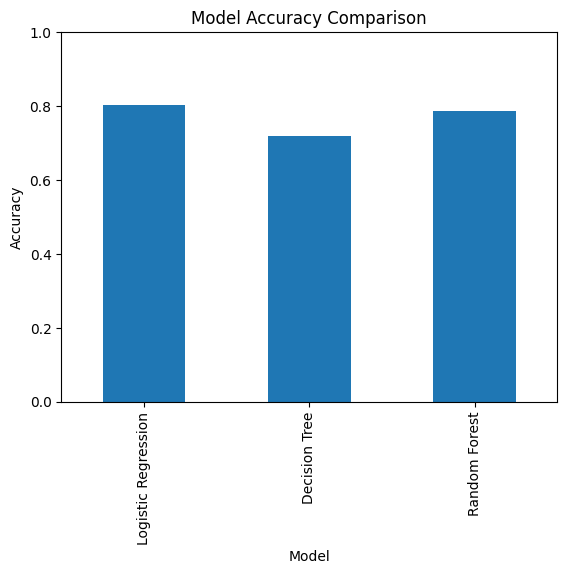

In [449]:
model_results.plot(x="Model", y="Accuracy", kind="bar", legend=False)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

## Cross-Validation

In this section,5-fold cross-validation is used to evaluate the stability of the models.

Compared with a single train-test split, cross-validation provides a more reliable estimate of model performance.

In [450]:
from sklearn.model_selection import cross_val_score

log_cv_scores = cross_val_score(
    log_model,
    X_train_scaled,
    y_train,
    cv = 5,
    scoring = "accuracy"
)

log_cv_scores

/Users/yu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/yu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weigh

array([0.78666667, 0.82044444, 0.80533333, 0.79111111, 0.80888889])

In [451]:
log_cv_scores.mean()

np.float64(0.802488888888889)

In [452]:
rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv = 5,
    scoring = "accuracy"
)

rf_cv_scores

array([0.78844444, 0.79555556, 0.78844444, 0.77511111, 0.78044444])

In [453]:
rf_cv_scores.mean()

np.float64(0.7856000000000001)

In [454]:
cv_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "CV Mean Accuracy": [log_cv_scores.mean(), rf_cv_scores.mean()]
})

cv_results

,Model,CV Mean Accuracy
0,Logistic Regression,0.802489
1,Random Forest,0.785600


The 5-fold cross-validation results show that Logistic Regression achieved a mean accuracy of 0.8025, while Random Forest achieved a mean accuracy of 0.7856.

These results are consistent with the previous train-test split evaluation, where Logistic Regression also achieved the best performance.

Therefore, Logistic Regression was selected as the best-performing model in this project.

## Hyperparameter Tuning

GridSearchCV is used to tune the hyperparameters of the Random Forest model.

This helps search for better parameter combinations and improve model performance.

In [455]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [456]:
grid_search.best_params_

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}

In [457]:
grid_search.best_score_

np.float64(0.8026666666666668)

In [458]:
best_rf_model = grid_search.best_estimator_

y_pred_best_rf = best_rf_model.predict(X_test)

accuracy_best_rf = accuracy_score(y_test, y_pred_best_rf)

accuracy_best_rf

0.7903340440653873

In [459]:
print(classification_report(y_test, y_pred_best_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



The GridSearchCV results show that the best Random Forest parameters were `max_depth=10`, `min_samples_split=2`, and `n_estimators=100`.  

After hyperparameter tuning, the Random Forest model achieved a test accuracy of 0.7903, which was slightly higher than the original Random Forest model.

However, the tuned Random Forest model still did not outperform Logistic Regression, which achieved a test accuracy of 0.8038.  

Therefore, Logistic Regression was selected as the best-performing model in this project.

In [460]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression", 
        "Decision Tree", 
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_log, 
        accuracy_tree,
        accuracy_rf, 
        accuracy_best_rf
    ]
})

final_results

,Model,Accuracy
0,Logistic Regression,0.803838
1,Decision Tree,0.718550
2,Random Forest,0.787491
3,Tuned Random Forest,0.790334


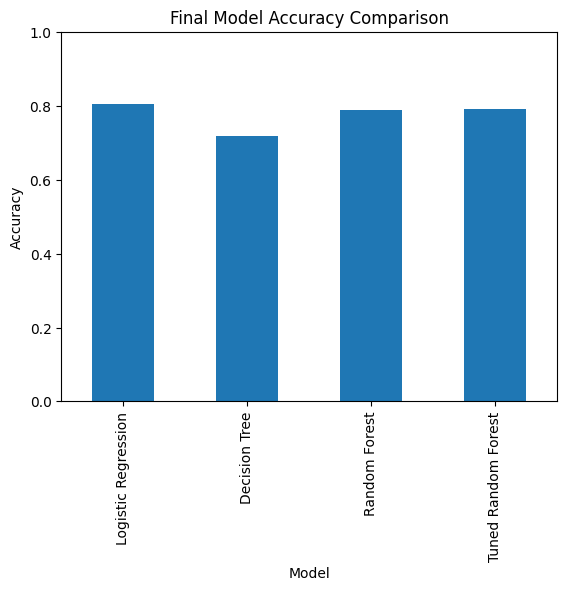

In [461]:
final_results.plot(x="Model", y="Accuracy", kind="bar", legend=False)

plt.title("Final Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

## Feature Importance Analysis

In this section, feature importance is analyzed using the Random Forest model.

This helps identify which customer features contribute more to churn prediction.

In [462]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.191748
1,tenure,0.170417
2,MonthlyCharges,0.168513
10,InternetService_Fiber optic,0.039125
28,PaymentMethod_Electronic check,0.037528
25,Contract_Two year,0.030091
4,gender_Male,0.029122
13,OnlineSecurity_Yes,0.028514
26,PaperlessBilling_Yes,0.025664
19,TechSupport_Yes,0.024337


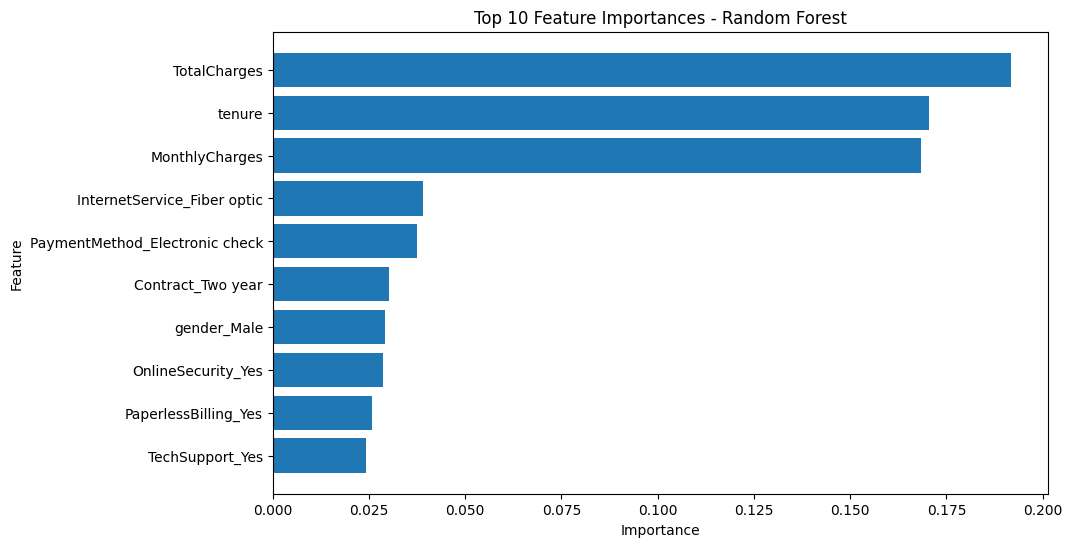

In [463]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The feature importance results from the Random Forest model show that 'TotalCharges', 'tenure', and 'MonthlyCharges' are the most important features for predicting customer churn. This suggests that customer spending behavior and service duration are strongly related to churn prediction.

In addition, service-related and contract-related features such as 'InternetService_Fiber optic', 'PaymentMethod_Electronic check', and 'Contract_Two year' also contributed to the prediction. This indicates that customers with different internet service types, payment methods, and contract types may have different churn patterns.

However, feature importance only shows which variables are influential in prediction. It does not directly indicate whether a feature increases or decreases churn probability.

## Project Conclusion

In this project, a customer churn prediction model was developed using the Telco Customer Churn dataset. The dataset was first cleaned by converting the 'TotalCharges' column into numeric format and removing missing values. Categorical variables were then encoded using one-hot encoding before model training.

Three machine learning models were trained and compared: Logistic Regression, Decision Tree, and Random Forest. Among these models, Logistic Regression achieved the highest accuracy of 0.8038, followed by Random Forest with an accuracy of 0.7875, while Decision Tree achieved an accuracy of 0.7185.

The feature importance analysis showed that 'TotalCharges', 'tenure', and 'MonthlyCharges' were the most important features for churn prediction. This indicates that customer spending behavior and service duration are closely related to customer churn.

Overall, the project demonstrates a complete machine learning workflow, including data preprocessing, exploratory data analysis, feature encoding, model training, model evaluation, and business interpretation.

## Save the Best Model

Since Logistic Regression achieved the best accuracy among the three models, it was selected as the final model.
The trained model and scaler are saved for future prediction or deployment.

In [464]:
import joblib
from pathlib import Path

# Create model folder path
model_dir = Path("../model")
model_dir.mkdir(exist_ok=True)

# Save model and scaler
joblib.dump(log_model, model_dir / "logistic_regression_model.pkl")
joblib.dump(scaler, model_dir / "scaler.pkl")

# Save feature columns
joblib.dump(X.columns.tolist(), model_dir / "feature_columns.pkl")

['../model/feature_columns.pkl']